# Що робить чел

## 1. починає з грід серча
2. взяв дані зображень цифр і буде їх класифікувати одиниця там чи ні, сплітнув
3. Створив свм і задав значення гамми
4. створив об'єкт грід серча - задава об'єкт моделі та сітку параметрів, вчить і чекає найліпший рез і параметр, gridsearch ще й cv робить за замовчуванням
5. затестив на окремих тест даних і подивився, чи нема перекосу в передбаченнях

6. Тепер пробує грід серч замість точності аук рок

7. грід серч з кількома гіперпараметрами із деревом рішень для раку грудей
8. витягає найкращі гіперпараметри із грід серча і вставляє їх класифікатору, вчить той класифікатор

## Наївний баєс

1. ф-ї для малювання

2. прості синтетичні дані
3. Юзає гаусівський баєс, який тупо норм розподіл накидає на дані?
4. сплітить дані, вчить баєс, евалуює і малює

5. складніші синтетичні дані
6. дав на нього гаусівський баєс і він побачив погано

7. рак грудей
8. теж гаусівський баєс і тут він передбачив добре

## Квиточки

Проблема: як дотримтатись оплати штрафів?
<br>
<br>Тре передбачити: передбачити чи буде тікет сплачено вчасно?

1. ~~зчитав тренувальні~~
2. ~~зчитав тест~~
3. ~~витяг допоміжні в датафрейми~~
4. ~~дропнув нани (нули) в таргеті~~
5. ~~змерджив додаткові і основний по адресах і айді тікетів~~
6. ~~створюють нову фічу: кількість часу між повідомленням про штраф і датої виплати, перед тим змінюючи типи і попередньо перевіривши їх~~
7. ~~видаляє лишні фічі~~
8. ~~енкодинг не чисельних фіч~~
9. ~~приберення нулів~~
10. ~~нормалізація~~
11. спроби різних класифікаторів: спершу ініціалізує грід серч, а далі пробує класифікатори

# Що робить мені

- лоад дані
- що з таргетом, чи є нулі
- викинути фічі такі як номер кабіни, embarked, фейр, номер тікета
- сумувати фічі батьків/дітей і братів/партнерів - розмір сім'ї (велика, маленька)

## Лоадінг даних

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [22]:
fp = 'titanic\\train.csv'
df_train = pd.read_csv(fp) 

In [23]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
ftest = 'titanic\\test.csv'
df_test = pd.read_csv(ftest) 
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


таргет має всі дані, вік і кабіна з ембаркд ні. двіостанні плануємо і так викидати

### створюємо нову фічу

думаю, що наявність своїх людей може підняти шанс на виживання

In [26]:
df_train['family_size'] = df_train['SibSp'] + df_train['Parch']
df_test['family_size'] = df_test['SibSp'] + df_test['Parch']
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [27]:
df_train['family_size'].describe()

count    891.000000
mean       0.904602
std        1.613459
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       10.000000
Name: family_size, dtype: float64

In [28]:
df_train.groupby("family_size")["Survived"].mean()

family_size
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

### видаляєм лишні фічі

In [29]:
cols_min = ['Pclass', 'Sex', 'Age', 'family_size', 'Fare']
X_train_min = df_train[cols_min]
X_test_min = df_test[cols_min]
y_train_min = df_train['Survived']
print(X_train_min.info())
print(X_test_min.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       891 non-null    int64  
 1   Sex          891 non-null    object 
 2   Age          714 non-null    float64
 3   family_size  891 non-null    int64  
 4   Fare         891 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       418 non-null    int64  
 1   Sex          418 non-null    object 
 2   Age          332 non-null    float64
 3   family_size  418 non-null    int64  
 4   Fare         417 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 16.5+ KB
None


варто заенкодити секс

### енкодинг не чисельних фіч

звісно вданому випадку унікальні дані колонки секс будуть однакові в обох і тест і трецн, але в загальному тре перевірити ну і можна 

In [30]:
print(X_train_min['Sex'].unique())
print(X_train_min['Sex'].unique())


['male' 'female']
['male' 'female']


In [32]:
X_train_min = X_train_min.copy() # to avoid warning related to setting the copy...
X_test_min = X_test_min.copy() # to avoid warning related to setting the copy...


le = LabelEncoder().fit(X_train_min['Sex']) # convert to str first since le may fail due to difference type of data
X_train_min['Sex'] = le.transform(X_train_min['Sex'])
X_test_min['Sex'] = le.transform(X_test_min['Sex'])

print(X_train_min.dtypes)
print(X_test_min.dtypes)


Pclass           int64
Sex              int64
Age            float64
family_size      int64
Fare           float64
dtype: object
Pclass           int64
Sex              int64
Age            float64
family_size      int64
Fare           float64
dtype: object


### приберення нулів

In [35]:
age_median = X_train_min['Age'].median()

X_train_min['Age'] = X_train_min['Age'].fillna(age_median)
X_test_min['Age'] = X_test_min['Age'].fillna(age_median)

X_test_min['Fare'] = X_test_min['Fare'].fillna(X_train_min['Fare'].median())

print(X_train_min.isna().any())
print(X_test_min.isna().any())

Pclass         False
Sex            False
Age            False
family_size    False
Fare           False
dtype: bool
Pclass         False
Sex            False
Age            False
family_size    False
Fare           False
dtype: bool


### нормалізація

In [38]:
cols_to_norm = ['Age', 'Fare', 'family_size']

# log transform тільки Fare
X_train_min['Fare'] = np.log1p(X_train_min['Fare'])
X_test_min['Fare'] = np.log1p(X_test_min['Fare'])

# потім нормалізація
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_min)
X_test_scaled = scaler.transform(X_test_min)

In [42]:
X_train_scaled[0]

array([1.        , 1.        , 0.27117366, 0.1       , 0.33812548])

### рандомний ліс

In [50]:
clf = RandomForestClassifier()       
grid_values = {'n_estimators': [20,50,200,300]}

In [54]:
grid_clf = GridSearchCV(clf, param_grid=grid_values)#,scoring='f1')
grid_clf.fit(X_train_scaled, y_train_min)
# grid_clf.fit(X_train_min, y_train_min)

print('Grid best parameter (max f1 ): ', grid_clf.best_params_) 
print('Grid best score (f1): ', grid_clf.best_score_) 

Grid best parameter (max f1 ):  {'n_estimators': 50}
Grid best score (f1):  0.8227292699767748


### predict

In [52]:
clf = RandomForestClassifier(n_estimators= 300)       
clf.fit(X_train_scaled, y_train_min)
y_predict= clf.predict(X_test_scaled)

### важливість фіч

In [57]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

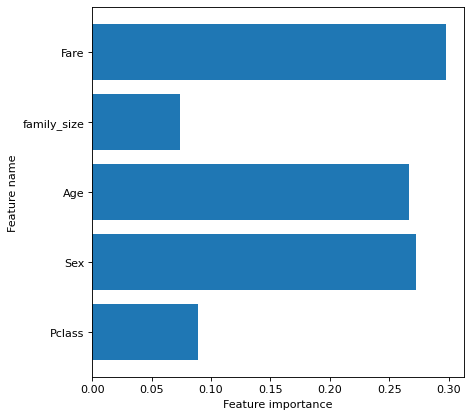

In [58]:
plot_feature_importances(clf, X_train_min.columns)
